<br />

<div style="text-align: center;">
<font size="5">数式処理 group work-4（線形代数の基本4空間）解答例</font>
</div>
<br />
<div style="text-align: right;">
<font size="4">file: four_spaces_qr_ans.ipynb</font>
<br />
<font size="4">cc by Shigeto R. Nishitani</font>
</div>

問題抽出メモ：
```bash
~/bin/pick_works_from_ans four_spaces_qr_ans.ipynb -1 '' '3 5 7 9 11 13 14 17'
```

# 行列と基本4空間

行列の基本４空間と呼ばれる図があります．
この図の意味がわかると代数計算，行列，写像が一度に理解できます．

![行列Aの基本4空間と線形写像の全体像](draw_four_spaces.004.png)
**参考図：行列 $A$ の基本4空間と線形写像**

このノートブックでは，次の行列を具体例として考えて行きます．

```python
A = Matrix([
    [1, 0, 0, 1, 2, 1],
    [0, 1, 0, 1, 1, 2],
    [0, 0, 1, 1, 1, 1],
    [1, 1, 0, 2, 3, 3],
])
```

行列$A\in\mathbb{R}^{m\times n}$，階数$r$ とよく書かれますが，
具体的な形をイメージするのがコツです．
この例では $4\times6$ 行列であり，$m=4$，$n=6$，階数は $r=3$ です．
行列 $A\in\mathbb{R}^{4\times 6}$ は，$6$ 次元のベクトル空間 $V$ から $4$ 次元のベクトル空間 $W$ への線形写像の表現行列になります．

以下ではこのpng図を作成するcodeを示していますが，
ChatGPTが作るcodeの出力は醜いのでコンセプトだけを抽出してください．


## 準備

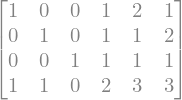

In [1]:
from sympy import Matrix, init_printing, latex
from IPython.display import Markdown, display
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Polygon, Rectangle

init_printing()

# [m, n, rank, 図の間隔, vの列数, uの列数, Sigmaを表示するか]
params = [
    [2, 6, 2, 5, 6, 2, 6],       # 2 x 6：SVD
    [4, 6, 3, 5, 1, 1, 0],       # 4 x 6（rank 3）
    [2, 2, 1, 2, 1, 1, 0],       # 2 x 2（rank 1）
    [5, 4, 3, 2, 1, 1, 0],       # 5 x 4（rank 3）：Mapleのparams[4]
    [4, 5, 3, 2, 1, 1, 0],       # 4 x 5（rank 3）
    [2, 3, 1, 2, 1, 1, 0],       # 2 x 3（rank 1）
]

a_m, a_n, a_r, width, n_v, n_u, n_s = params[1]  # Mapleのparams[2]

A = Matrix([
    [1, 0, 0, 1, 2, 1],
    [0, 1, 0, 1, 1, 2],
    [0, 0, 1, 1, 1, 1],
    [1, 1, 0, 2, 3, 3],
])
A

## (a) 行列積 $A\boldsymbol{v}=\boldsymbol{w}$ の次元対応

$A$ が $m\times n$ 行列ならば，$A$ は $n$ 次元ベクトルを $m$ 次元ベクトルへ写します．行列積が定義できるためには，$A$ の列数と $\boldsymbol{v}$ の行数が一致しなければなりません．

以下の関数は行列積の次元対応を視覚的に確認する関数です．
下の方の課題でも多用しますので，実行例とコメントを読んで使い方に習熟してください．

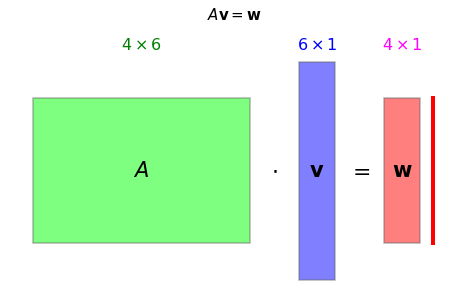

(<Figure size 600.48x360 with 1 Axes>,
 <AxesSubplot:title={'center':'$A\\mathbf{v}=\\mathbf{w}$'}>)

In [2]:
def draw_matrix_equation_dimensions(factors, operators, title=None):
    """複数の行列と演算子を1本の式として描きます．

    factorsの各要素は(rows, columns, label, color[, pattern])です．
    patternにはdense，diagonal，upper，('rref', rank)を指定できます．
    rowsまたはcolumnsが0なら，長方形の代わりに線を描きます．
    operatorsには隣り合う因子間の演算子を指定します．
    空文字列を指定すると，演算子を置かずに間隔だけ空けます．
    """
    if len(operators) != len(factors) - 1:
        raise ValueError('operatorsの個数はfactorsより1個少なくしてください．')

    parsed = []
    for factor in factors:
        if len(factor) == 4:
            rows, columns, label, color = factor
            pattern = 'dense'
        elif len(factor) == 5:
            rows, columns, label, color, pattern = factor
        else:
            raise ValueError('factorは4要素または5要素で指定してください．')
        rows, columns = int(rows), int(columns)
        if rows < 0 or columns < 0:
            raise ValueError('行数と列数には0以上の整数を指定してください．')
        if isinstance(pattern, tuple):
            pattern_name, pattern_rank = pattern
        else:
            pattern_name, pattern_rank = pattern, min(rows, columns)
        if pattern_name not in {'dense', 'diagonal', 'upper', 'rref'}:
            raise ValueError(f'未知のpatternです：{pattern_name}')
        pattern_rank = max(0, min(int(pattern_rank), rows, columns))
        parsed.append((rows, columns, label, color,
                       pattern_name, pattern_rank))

    normal_gap = 1.35
    empty_gap = 0.30
    positions = []
    operator_positions = []
    cursor = 0.0

    for index, (rows, columns, label, color,
                pattern_name, pattern_rank) in enumerate(parsed):
        visual_width = columns if columns > 0 else 0.12
        positions.append((cursor, visual_width))
        cursor += visual_width
        if index < len(operators):
            gap = empty_gap if operators[index] == '' else normal_gap
            operator_positions.append(cursor + gap/2)
            cursor += gap

    max_rows = max([rows for rows, _, _, _, _, _ in parsed] + [1])
    top = max_rows/2 + 0.35
    fig_width = max(8.0, min(16.0, 0.75*cursor))
    fig, ax = plt.subplots(figsize=(fig_width, 5))
    edge = '#666666'

    def lighten(color, amount=0.82):
        rgb = np.asarray(plt.matplotlib.colors.to_rgb(color))
        return tuple(rgb + (1.0-rgb)*amount)

    for factor, (x_pos, visual_width) in zip(parsed, positions):
        rows, columns, label, color, pattern_name, pattern_rank = factor
        center_x = x_pos + visual_width/2
        if rows > 0 and columns > 0:
            base_color = color if pattern_name == 'dense' else lighten(color)
            base_alpha = 0.50 if pattern_name == 'dense' else 1.00
            ax.add_patch(Rectangle((x_pos, -rows/2), columns, rows,
                                   facecolor=base_color, alpha=base_alpha,
                                   edgecolor=edge, lw=1.5))

            if pattern_name == 'diagonal':
                for i in range(pattern_rank):
                    ax.add_patch(Rectangle(
                        (x_pos+i, rows/2-i-1), 1, 1,
                        facecolor=color, alpha=0.78, edgecolor='none'))
            elif pattern_name in {'upper', 'rref'}:
                active_rows = (min(rows, columns) if pattern_name == 'upper'
                               else pattern_rank)
                for i in range(active_rows):
                    ax.add_patch(Rectangle(
                        (x_pos+i, rows/2-i-1), columns-i, 1,
                        facecolor=color, alpha=0.62, edgecolor='none'))
                    if pattern_name == 'rref':
                        ax.add_patch(Rectangle(
                            (x_pos+i, rows/2-i-1), 1, 1,
                            facecolor=color, alpha=0.92, edgecolor='none'))

            if label:
                ax.text(center_x, 0, f'${label}$',
                        ha='center', va='center', fontsize=21)
            dim_color = {'lime': 'green', 'red': 'magenta'}.get(color, color)
            ax.text(center_x, top, rf'${rows}\times {columns}$',
                    color=dim_color, ha='center', fontsize=16)
        elif columns == 0 and rows > 0:
            ax.plot([center_x, center_x], [-rows/2, rows/2],
                    color=color, lw=4)
        elif rows == 0 and columns > 0:
            ax.plot([x_pos, x_pos+columns], [0, 0], color=color, lw=4)
        else:
            ax.plot(center_x, 0, marker='o', color=color, markersize=4)

    for operator, x_pos in zip(operators, operator_positions):
        if operator:
            ax.text(x_pos, 0, f'${operator}$',
                    ha='center', va='center', fontsize=22)

    ax.set_xlim(-0.7, cursor+0.7)
    ax.set_ylim(-max_rows/2-0.5, top+0.65)
    ax.set_aspect('equal')
    ax.axis('off')
    if title is not None:
        ax.set_title(title, fontsize=15)
    plt.show()
    return fig, ax


draw_matrix_equation_dimensions(
    factors=[
        (a_m, a_n, 'A', 'lime'),
        (a_n, 1, r'\mathbf{v}', 'blue'),
        (a_m, 1, r'\mathbf{w}', 'red'),
        (a_m, 0, '', 'red'),  # 0列は縦線だけを表示します．
    ],
    operators=[r'\cdot', '=', ''],
    title=r'$A\mathbf{v}=\mathbf{w}$',
)

## (b) 行階段形と階数

掃き出しによって得られる階段形では，主成分（pivot）の個数が階数 $r$ になります．したがって，主成分を含む列から列空間の基底が得られ，自由変数の個数 $n-r$ から零空間の次元が分かります．

次元表示関数の第5要素には，全面を塗る`dense`，対角成分を示す`diagonal`，上三角を示す`upper`，階数も指定する`('rref', r)`を使用できます．構造を指定した行列では，濃色が非零成分の入り得る領域，淡色が構造上 0 となる領域を表します．例えば，SVD の $\Sigma$ は`(*Sigma.shape, r'\Sigma', 'red', 'diagonal')`と指定できます．

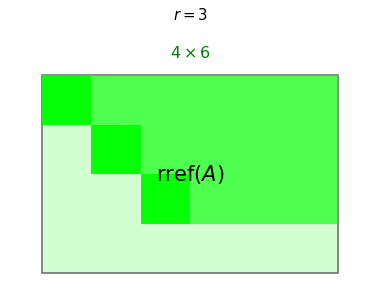

(<Figure size 576x360 with 1 Axes>, <AxesSubplot:title={'center':'$r=3$'}>)

In [3]:
draw_matrix_equation_dimensions(
    factors=[
        (a_m, a_n, r'\mathrm{rref}(A)', 'lime', ('rref', a_r)),
    ],
    operators=[],
    title=rf'$r={a_r}$',
)

## (c) 線形写像 $A:V\to W$ の核と像

$A$ は $V=\mathbb{R}^n$ を $W=\mathbb{R}^m$ へ写します．そのとき，零空間 $\mathrm{Ker}(A)$ のベクトルは $\boldsymbol{0}$ へ写り，$A$ による像全体が $\mathrm{Im}(A)=C(A)$ になります．

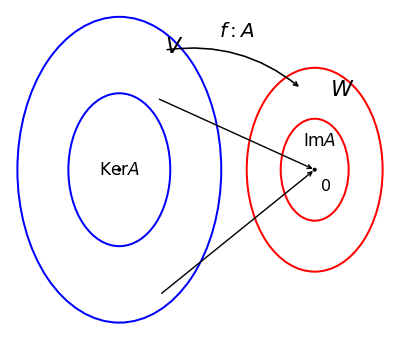

In [4]:
k_ratio = a_n/a_r
ellipse_aspect = 2/3
x_left = -a_n*ellipse_aspect - 0.5
x_right = a_m*ellipse_aspect + 0.5

# Mapleのellipseは第2，第3引数を横半径，縦半径としています
ellipse_data = [
    (a_n*ellipse_aspect, a_n, 'blue', x_left),
    (a_n*ellipse_aspect/k_ratio, a_n/k_ratio, 'blue', x_left),
    (a_m*ellipse_aspect, a_m, 'red', x_right),
    (a_m*ellipse_aspect/k_ratio, a_m/k_ratio, 'red', x_right),
    (0.04, 0.04, 'black', x_left),
    (0.04, 0.04, 'black', x_right),
]

fig, ax = plt.subplots(figsize=(10, 6))
for radius_x, radius_y, color, center_x in ellipse_data:
    ax.add_patch(Ellipse((center_x, 0), 2*radius_x, 2*radius_y,
                         fill=False, edgecolor=color, lw=2))

# PNGに対応する線形写像，核，像です
ax.text(x_left+1.8, 4.6, r'$V$', fontsize=22)
ax.text(x_right+0.6, 2.9, r'$W$', fontsize=22)
ax.text(x_left, 0.0, r'$\mathrm{Ker}A$', ha='center', va='center', fontsize=17)
ax.text(x_right+0.2, 1.15, r'$\mathrm{Im}A$', ha='center', va='center', fontsize=17)
ax.text(x_right+0.2, -0.8, r'$0$', fontsize=16)
ax.annotate('', xy=(x_right-0.55, 3.2), xytext=(x_left+1.8, 4.7),
            arrowprops=dict(arrowstyle='->', lw=1.6, color='black',
                            connectionstyle='arc3,rad=-0.22'))
ax.text(-0.6, 5.25, r'$f:A$', fontsize=20)
ax.annotate('', xy=(x_right, 0.0), xytext=(x_left+1.5, 2.8),
            arrowprops=dict(arrowstyle='->', lw=1.4, color='black'))
ax.annotate('', xy=(x_right, 0.0), xytext=(x_left+1.6, -4.9),
            arrowprops=dict(arrowstyle='->', lw=1.4, color='black'))

ax.set_xlim(x_left-a_n*ellipse_aspect-0.4,
            x_right+a_m*ellipse_aspect+0.4)
ax.set_ylim(-a_n-0.4, a_n+0.4)
ax.set_aspect('equal')
ax.axis('off')
plt.show()

## (d) 行列 $A$ の基本4空間

行列 $A\in\mathbb{R}^{m\times n}$ の階数を $r$ とします．基本4空間とその次元は次のとおりです．

<div style="overflow-x: auto;">
<table style="min-width: 620px; width: 100%; table-layout: auto;">
  <thead>
    <tr>
      <th style="white-space: nowrap; text-align: left;">基本空間</th>
      <th style="white-space: nowrap; text-align: center;">属する空間</th>
      <th style="white-space: nowrap; text-align: center;">次元</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="white-space: nowrap;">行空間 \(C(A^T)\)</td>
      <td style="white-space: nowrap; text-align: center;">\(\mathbb{R}^n=\mathbb{R}^6\)</td>
      <td style="white-space: nowrap; text-align: center;">\(r=3\)</td>
    </tr>
    <tr>
      <td style="white-space: nowrap;">零空間 \(N(A)\)</td>
      <td style="white-space: nowrap; text-align: center;">\(\mathbb{R}^n=\mathbb{R}^6\)</td>
      <td style="white-space: nowrap; text-align: center;">\(n-r=3\)</td>
    </tr>
    <tr>
      <td style="white-space: nowrap;">列空間 \(C(A)\)</td>
      <td style="white-space: nowrap; text-align: center;">\(\mathbb{R}^m=\mathbb{R}^4\)</td>
      <td style="white-space: nowrap; text-align: center;">\(r=3\)</td>
    </tr>
    <tr>
      <td style="white-space: nowrap;">左零空間 \(N(A^T)\)</td>
      <td style="white-space: nowrap; text-align: center;">\(\mathbb{R}^m=\mathbb{R}^4\)</td>
      <td style="white-space: nowrap; text-align: center;">\(m-r=1\)</td>
    </tr>
  </tbody>
</table>
</div>

同じ側にある2空間は互いに直交し，$\mathbb{R}^n=C(A^T)\oplus N(A)$，$\mathbb{R}^m=C(A)\oplus N(A^T)$ となります．

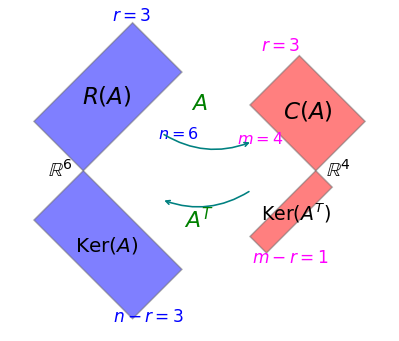

In [5]:
def rectangle_points(x0, y0, x1, y1):
    return np.array([[x0, y0], [x1, y0], [x1, y1], [x0, y1]])

def rotate_45(points):
    theta = np.pi/4
    rotation = np.array([[np.cos(theta), -np.sin(theta)],
                         [np.sin(theta),  np.cos(theta)]])
    return points @ rotation.T

# Mapleで定義した4個の長方形です
r_a = rectangle_points(0, 0, a_n, a_r)
n_a = rectangle_points(-(a_n-a_r), -a_n, 0, 0)
c_a = rectangle_points(0, 0, a_m, a_r)
n_at = rectangle_points(-(a_m-a_r), -a_m, 0, 0)

# 左側は回転して-widthだけ移動します
left_rects = [rotate_45(p) + np.array([-width, 0]) for p in (r_a, n_a)]
# 右側は回転後にy軸で反転し，+widthだけ移動します
right_rects = []
for points in (c_a, n_at):
    transformed = rotate_45(points)
    transformed[:, 0] *= -1
    right_rects.append(transformed + np.array([width, 0]))

fig, ax = plt.subplots(figsize=(10, 6))
for points in left_rects:
    ax.add_patch(Polygon(points, closed=True, facecolor='blue',
                         alpha=0.50, edgecolor='#666666', lw=1.5))
for points in right_rects:
    ax.add_patch(Polygon(points, closed=True, facecolor='red',
                         alpha=0.50, edgecolor='#666666', lw=1.5))

# PNGに対応する4空間名，次元，写像です
ax.text(-4.0, 3.2, r'$R(A)$', ha='center', va='center', fontsize=23)
ax.text(-4.0, -3.2, r'$\mathrm{Ker}(A)$', ha='center', va='center', fontsize=20)
ax.text(4.65, 2.55, r'$C(A)$', ha='center', va='center', fontsize=23)
ax.text(4.15, -1.8, r'$\mathrm{Ker}(A^T)$', ha='center', va='center', fontsize=19)
ax.text(-5.45, -0.25, rf'$\mathbb{{R}}^{a_n}$', ha='right', fontsize=20)
ax.text(5.45, -0.25, rf'$\mathbb{{R}}^{a_m}$', ha='left', fontsize=20)
ax.text(-2.9, 6.45, rf'$r={a_r}$', color='blue', ha='center', fontsize=17)
ax.text(-2.2, -6.5, rf'$n-r={a_n-a_r}$', color='blue', ha='center', fontsize=17)
ax.text(3.5, 5.15, rf'$r={a_r}$', color='magenta', ha='center', fontsize=17)
ax.text(3.9, -3.95, rf'$m-r={a_m-a_r}$', color='magenta', ha='center', fontsize=17)
ax.text(-1.8, 1.4, rf'$n={a_n}$', color='blue', fontsize=16)
ax.text(1.6, 1.15, rf'$m={a_m}$', color='magenta', fontsize=16)
ax.annotate('', xy=(2.25, 1.25), xytext=(-1.6, 1.6),
            arrowprops=dict(arrowstyle='->', color='teal', lw=1.6,
                            connectionstyle='arc3,rad=0.25'))
ax.annotate('', xy=(-1.6, -1.25), xytext=(2.2, -0.85),
            arrowprops=dict(arrowstyle='->', color='teal', lw=1.6,
                            connectionstyle='arc3,rad=-0.25'))
ax.text(0.0, 2.65, r'$A$', color='green', ha='center', fontsize=22)
ax.text(0.0, -2.45, r'$A^T$', color='green', ha='center', fontsize=22)

all_points = np.vstack(left_rects + right_rects)
ax.set_xlim(all_points[:, 0].min()-1.15, all_points[:, 0].max()+1.15)
ax.set_ylim(all_points[:, 1].min()-0.65, all_points[:, 1].max()+0.65)
ax.set_aspect('equal')
ax.axis('off')
plt.show()

## SymPyで基本4空間を求める

次の $4\times6$ 行列は階数3です．`columnspace`，`rowspace`，`nullspace` を使い，4空間の基底と次元を確かめます．

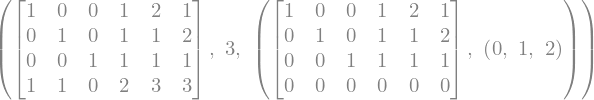

In [6]:
A, A.rank(), A.rref()

In [7]:
four_spaces = {
    r'行空間 $C(A^T)$': A.rowspace(),
    r'零空間 $N(A)$': A.nullspace(),
    r'列空間 $C(A)$': A.columnspace(),
    r'左零空間 $N(A^T)$': A.T.nullspace(),
}

rows = [
    '| 空間 | 次元 | 基底ベクトルのリスト |',
    '|:--|:--|:--|',
]
for name, basis in four_spaces.items():
    basis_list = r'$\left\{' + r','.join(latex(vector) for vector in basis) + r'\right\}$'
    #print(basis_list)
    rows.append(f'| {name} | {len(basis)} | {basis_list} |')

display(Markdown('\n'.join(rows)))

| 空間 | 次元 | 基底ベクトルのリスト |
|:--|:--|:--|
| 行空間 $C(A^T)$ | 3 | $\left\{\left[\begin{matrix}1 & 0 & 0 & 1 & 2 & 1\end{matrix}\right],\left[\begin{matrix}0 & 1 & 0 & 1 & 1 & 2\end{matrix}\right],\left[\begin{matrix}0 & 0 & 1 & 1 & 1 & 1\end{matrix}\right]\right\}$ |
| 零空間 $N(A)$ | 3 | $\left\{\left[\begin{matrix}-1\\-1\\-1\\1\\0\\0\end{matrix}\right],\left[\begin{matrix}-2\\-1\\-1\\0\\1\\0\end{matrix}\right],\left[\begin{matrix}-1\\-2\\-1\\0\\0\\1\end{matrix}\right]\right\}$ |
| 列空間 $C(A)$ | 3 | $\left\{\left[\begin{matrix}1\\0\\0\\1\end{matrix}\right],\left[\begin{matrix}0\\1\\0\\1\end{matrix}\right],\left[\begin{matrix}0\\0\\1\\0\end{matrix}\right]\right\}$ |
| 左零空間 $N(A^T)$ | 1 | $\left\{\left[\begin{matrix}-1\\-1\\0\\1\end{matrix}\right]\right\}$ |

## 確認

この例では $m=4$，$n=6$，$r=3$ です．したがって，

- $\dim C(A)=\dim C(A^T)=3$
- $\dim N(A)=6-3=3$
- $\dim N(A^T)=4-3=1$

となり，SymPyで得た基底の本数と一致します．

# 二次関数fittingからQR分解へ

Breast Cancer Detectorの課題で取り上げたQR分解は最小二乗法による
近似にとても便利な線形代数の計算法です．
これをよく理解するために課題に取り組んでもらいます．
以下の記述をゆっくりとフォローしてください．


4個のデータ点

$$
(x_i,b_i)=(0,1),(1,2),(2,2),(3,4)
$$

を二次関数

$$
\widehat{b}(x)=w_0+w_1x+w_2x^2
$$

で近似します．パラメータベクトルは $\boldsymbol{w}=[w_0,w_1,w_2]^T$ です．

フィッティングされるデザイン行列 $A_{\mathrm{fit}}$ の各行は $[1,x_i,x_i^2]$ となります．
これはVandermont行列と呼ばれるよく出てくる行列です．
予測値は $A_{\mathrm{fit}}\boldsymbol{w}$ になります．

残差 $A_{\mathrm{fit}}\boldsymbol{w}-\boldsymbol{b}$ を使い，

$$
J(\boldsymbol{w})=\frac{1}{2}\left\|A_{\mathrm{fit}}\boldsymbol{w}-\boldsymbol{b}\right\|_2^2
$$

を最小にする $\boldsymbol{w}$ を求めます．以下のすべての課題で，同じ $A_{\mathrm{fit}}$ を使ってください．

## 課題1：デザイン行列と行列積の次元対応

前半の「(a) 行列積 $A\boldsymbol{v}=\boldsymbol{w}$ の次元対応」を参考に，次を行ってください．

1. $A_{\mathrm{fit}}$，$\boldsymbol{w}$，$A_{\mathrm{fit}}\boldsymbol{w}$，$\boldsymbol{b}$のshapeを書いてください．
2. `shape`を表示し，行列積の内側の次元が一致することを確認してください．
3. 前半(a)で定義した`draw_matrix_equation_dimensions`へ，因子の行数・列数・ラベル・色と，因子間の演算子を渡し，$A_{\mathrm{fit}}\boldsymbol{w}=\widehat{\boldsymbol{b}}$の次元対応を1枚に表示してください．
4. パラメータが直線近似より1個増えたことで，デザイン行列のどの次元が変わったか説明してください．

## 課題2：QR分解による二次関数fitting

$A_{\mathrm{fit}}$をreduced QR分解して，

$$
A_{\mathrm{fit}}=QR,\qquad R\boldsymbol{w}=Q^T\boldsymbol{b}
$$

から最小二乗解を求めてください．

1. `np.linalg.qr(A_fit, mode='reduced')`で$Q$と$R$を求めてください．
2. $A_{\mathrm{fit}}=QR$と$R\boldsymbol{w}=Q^T\boldsymbol{b}$について，計算前に各因子のshapeを予想してください．その後，前半(a)の`draw_matrix_equation_dimensions`へ因子と演算子を渡し，それぞれの等式全体を1枚ずつ表示してください．
3. `np.linalg.solve`を使って$R\boldsymbol{w}=Q^T\boldsymbol{b}$を解いてください．逆行列を明示的に作ってはいけません．
4. $Q^TQ=I$と$A_{\mathrm{fit}}=QR$を`np.allclose`で確認してください．
5. データ点と，得られた二次関数を同じグラフに描いてください．曲線を滑らかに表示するため，細かい$x$の配列を別に作ってください．
6. 最小二乗損失$J(\boldsymbol{w})$を表示してください．

## 課題3：Gram–Schmidt法による$Q$と$R$の構成

$A_{\mathrm{fit}}$の3本の列を $\boldsymbol{v}_1,\boldsymbol{v}_2,\boldsymbol{v}_3$ とし，Gram–Schmidt法を適用してください．

$$
\boldsymbol{u}_1=\boldsymbol{v}_1,\qquad
\boldsymbol{u}_j=\boldsymbol{v}_j-\sum_{i=1}^{j-1}
\frac{\boldsymbol{u}_i^T\boldsymbol{v}_j}{\boldsymbol{u}_i^T\boldsymbol{u}_i}\boldsymbol{u}_i,\qquad
\boldsymbol{q}_i=\frac{\boldsymbol{u}_i}{\|\boldsymbol{u}_i\|_2}.
$$

1. $A_{\mathrm{fit}}$の各列から$\boldsymbol{u}_1,\boldsymbol{u}_2,\boldsymbol{u}_3$を求めてください．
2. 正規化して$\boldsymbol{q}_1,\boldsymbol{q}_2,\boldsymbol{q}_3$を求め，列に並べて$Q_{\mathrm{GS}}$を作ってください．
3. $R_{\mathrm{GS}}=Q_{\mathrm{GS}}^TA_{\mathrm{fit}}$を求めてください．
4. $Q_{\mathrm{GS}}^TQ_{\mathrm{GS}}=I$，$A_{\mathrm{fit}}=Q_{\mathrm{GS}}R_{\mathrm{GS}}$を確認してください．
5. 課題2の`np.linalg.qr`の結果と比較してください．列ベクトルの符号が異なっても，同じQR分解を表せる理由を説明してください．
6. `draw_matrix_equation_dimensions`へ$A_{\mathrm{fit}}$，$Q_{\mathrm{GS}}$，$R_{\mathrm{GS}}$と演算子を渡し，$A_{\mathrm{fit}}=Q_{\mathrm{GS}}R_{\mathrm{GS}}$を1枚に表示してください．課題2の表示と一致することも確認してください．

提出時には，課題1の次元対応図，課題2のfitting図，すべてのshape，検算結果，および考察を残してください．